In [3]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market import Market

In [4]:
import src
from importlib import reload
reload(src.Market)
from src.Market import Market

## The market process

In [5]:
import yfinance as yf

data = yf.download('^GSPC',start="2010-01-01", end='2021-01-01')

[*********************100%***********************]  1 of 1 completed


In [6]:
p_t = data['Close']['^GSPC']

In [7]:
r_m = np.log(p_t) - np.log(p_t.shift(1))

In [8]:
r_m.dropna(inplace=True)

In [9]:
from itertools import product
from arch import arch_model

param_set = {
    'p':[1,2],
    'q':[0,1,2],
    'dist': ['t', 'skewt']
}

combinations = [dict(zip(param_set.keys(), combo)) for combo in product(*param_set.values())]

bics = {}

for c in combinations:
    market_model = arch_model(100*r_m, mean='AR', lags=1, vol='GARCH', p=c['p'], q=c['q'], dist=c['dist']).fit(disp=False)
    bics[c.values()] = market_model.bic

In [10]:
pd.DataFrame(bics.items(), columns=['params', 'bic']).sort_values('bic')

,params,bic
3,"(1, 1, skewt)",6738.804741
9,"(2, 1, skewt)",6739.101445
11,"(2, 2, skewt)",6746.010850
5,"(1, 2, skewt)",6746.730259
2,"(1, 1, t)",6755.447589
8,"(2, 1, t)",6757.197312
4,"(1, 2, t)",6763.373108
10,"(2, 2, t)",6764.049715
6,"(2, 0, t)",6973.221626
7,"(2, 0, skewt)",6974.221955


In [11]:
market_model = arch_model(100*r_m, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='skewt').fit(disp=False)

In [12]:
market_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 AR - GARCH Model Results                                
=========================================================================================
Dep. Variable:                             ^GSPC   R-squared:                       0.017
Mean Model:                                   AR   Adj. R-squared:                  0.017
Vol Model:                                 GARCH   Log-Likelihood:               -3341.66
Distribution:      Standardized Skew Student's t   AIC:                           6697.33
Method:                       Maximum Likelihood   BIC:                           6738.80
                                                   No. Observations:                 2767
Date:                           Wed, Apr 29 2026   Df Residuals:                     2765
Time:                                   20:50:36   Df Model:                            2
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0763  1.336e-02      5.713  1.107e-08  [5.014e-02,  0.103]
^GSPC[1]      -0.0801  1.920e-02     -4.172  3.026e-05 [ -0.118,-4.246e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0233  5.240e-03      4.455  8.376e-06 [1.308e-02,3.362e-02]
alpha[1]       0.1707  2.071e-02      8.240  1.721e-16     [  0.130,  0.211]
beta[1]        0.8174  1.865e-02     43.827      0.000     [  0.781,  0.854]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta            5.4126      0.552      9.803  1.097e-22    [  4.330,  6.495]
lambda        -0.1293  2.496e-02     -5.180  2.218e-07 [ -0.178,-8.036e-02]
===========================================================================

Covariance estimator: robust
"""

In [13]:
class skew_t_quantile():
    def __init__(self):
        self.name = "skew_t"
    def ppf(q):
        return market_model.model.distribution.ppf(parameters=market_model.params[-2:].values, pits=q)

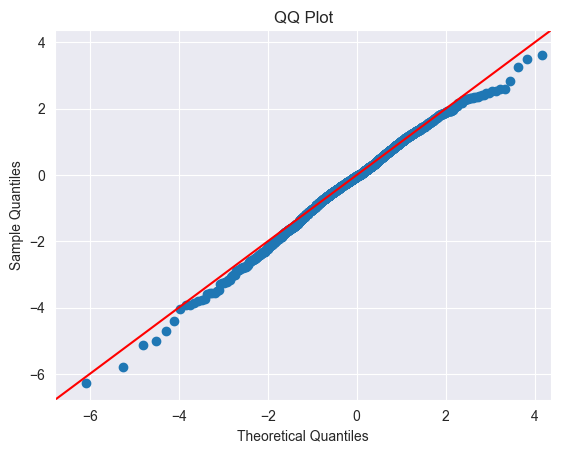

In [14]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(market_model.std_resid, dist=skew_t_quantile, line='45')
plt.title("QQ Plot")
plt.show()

<Axes: xlabel='Date'>

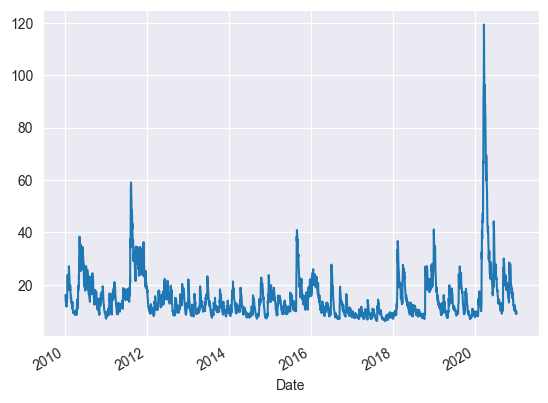

In [15]:
(market_model.conditional_volatility * np.sqrt(252)).plot()

## Whole Market simulation

In [89]:
from joblib import dump, load

market = Market(20, 5, market_model, rf = 0.0001, market_scale_arch=100 * 2)
dump(market, project_root / "results/market_simulation.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\market_simulation.joblib']

In [90]:
sims = []
ms = []

for i in range(150):
    sim, m, vol = market.simulate(2520, initial_value=-0.2, initial_vol=0.5, burn=0)
    sims.append(sim)
    ms.append(m)

In [91]:
sims = np.array(sims)
ms = np.array(ms)

<Axes: >

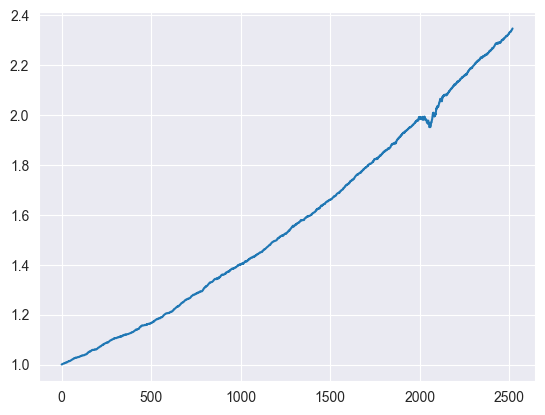

In [92]:
ms = pd.DataFrame(ms)

np.exp(ms.mean()).cumprod().plot(legend=False)

In [93]:
ms.mean().mean() # target 0.000228

np.float64(0.00033857601879403126)

In [94]:
sims.max()

np.float64(1.1595824975290288)

In [95]:
market.summary()

,alpha,beta,vols,sector,sector_coeffs,sector_vols
0,0.000050,1.293130,0.006717,1,0.852357,0.005486
1,-0.000014,0.954845,0.005649,0,0.640602,0.005977
2,0.000065,1.013506,0.005437,4,0.724074,0.004416
3,0.000152,0.715050,0.004518,2,0.269930,0.013382
4,-0.000023,0.891123,0.003274,3,0.557217,0.004081
5,-0.000023,1.022185,0.004120,2,0.222469,0.013382
6,0.000158,0.769801,0.004338,2,0.252708,0.013382
7,0.000077,1.075140,0.007424,0,0.871854,0.005977
8,-0.000047,0.879872,0.006219,2,0.284288,0.013382
9,0.000054,0.941661,0.003235,4,0.413006,0.004416


<Axes: >

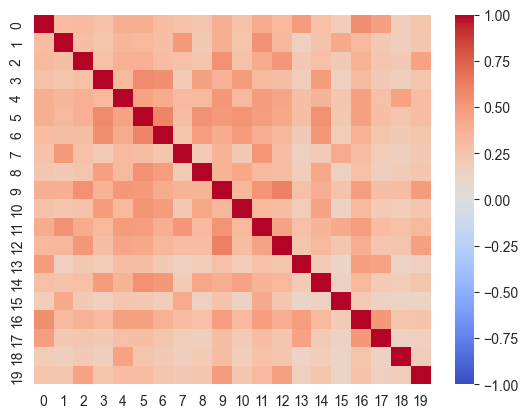

In [96]:
sim0 = pd.DataFrame(sims[5])
sns.heatmap(sim0.corr(), vmin=-1, vmax=1, cmap='coolwarm')

In [97]:
ms.std()

0       0.003638
1       0.003563
2       0.003564
3       0.003643
4       0.004096
          ...   
2515    0.005052
2516    0.004748
2517    0.005164
2518    0.004906
2519    0.005147
Length: 2520, dtype: float64

<Axes: >

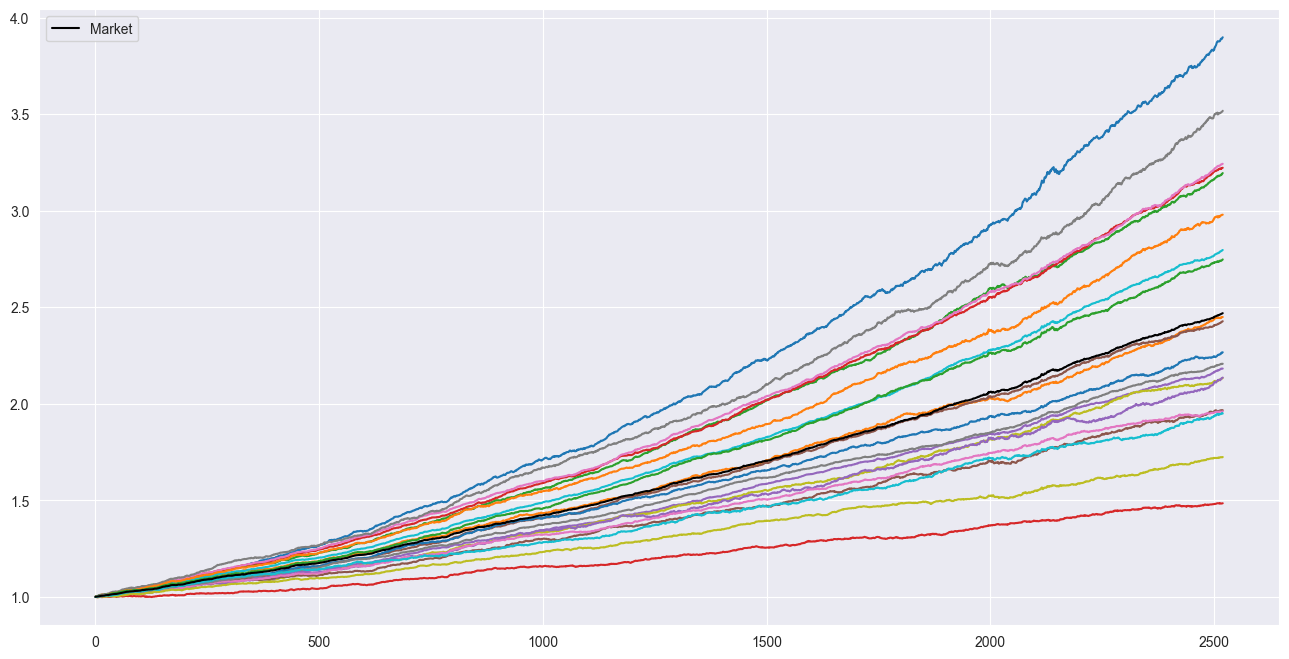

In [98]:
for i in range(20):
    asset_returns = pd.DataFrame(sims[:, :, i])

    np.exp(asset_returns).cumprod(axis=1).mean().plot(legend=False, label=f'Asset {i+1}', figsize=(16,8))
np.exp(ms).cumprod(axis=1).mean().plot(legend=True, label=f'Market', figsize=(16,8), color='black')

<Axes: >

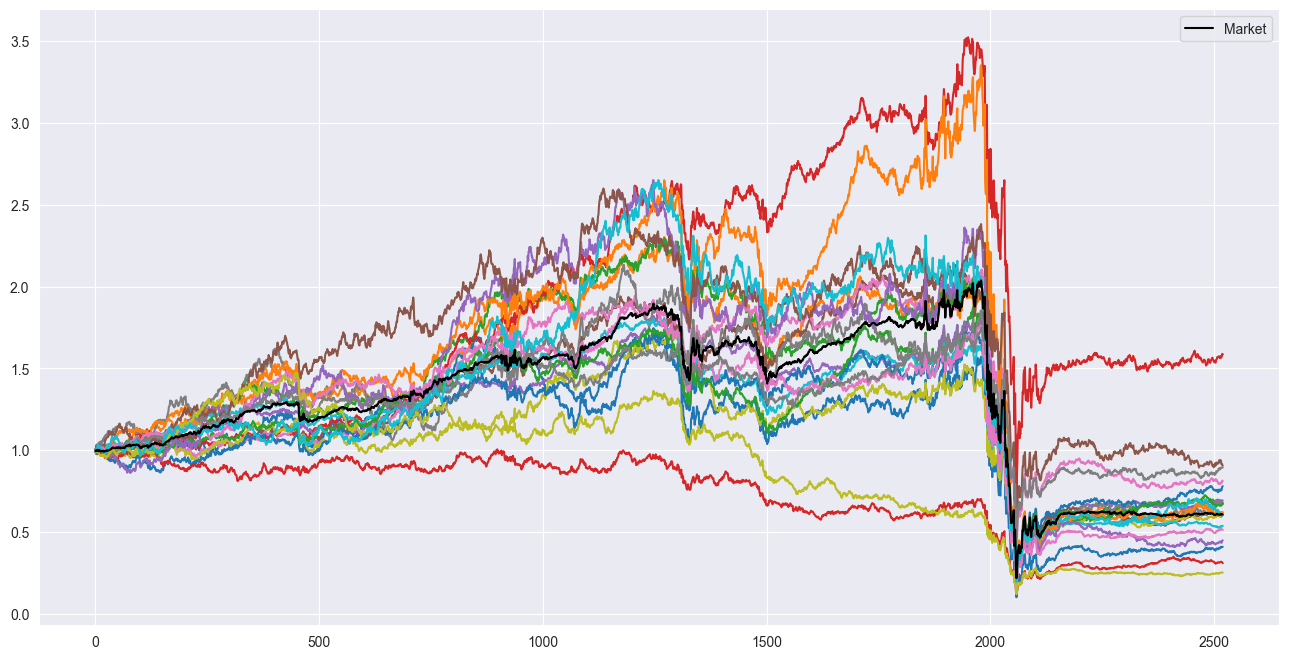

In [112]:
fig, ax = plt.subplots(1,1)

for i in range(20):
    asset_returns = pd.DataFrame(sims[3, :, i])

    np.exp(asset_returns).cumprod().plot(legend=False, label=f'Asset {i+1}', figsize=(16,8), ax=ax)

np.exp(ms.loc[3]).cumprod().plot(legend=True, label=f'Market', figsize=(16,8), color='black', ax=ax)

In [107]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

capm = {}

for i in range(20):
    capm[i] = linear_model.OLS(sims[10, :, i], sm.add_constant(ms.loc[10])).fit()

In [ ]:
capm[10].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     680.8
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          4.92e-133
Time:                        20:17:55   Log-Likelihood:                 8835.6
No. Observations:                2520   AIC:                        -1.767e+04
Df Residuals:                    2518   BIC:                        -1.766e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -1.507      0.132      -0.001    6.61e-05
3              0.8763      0.034     26.092      0.000       0.810       0.942
==============================================================================
Omnibus:                        4.951   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.084   Jarque-Bera (JB):                4.966
Skew:                          -0.085   Prob(JB):                       0.0835
Kurtosis:                       3.135   Cond. No.                         232.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""